Modelo de Regressão Logística

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# importação dos arquivos
df_train = pd.read_csv("./dados_projeto/treino.csv")
df_test1 = pd.read_csv("./dados_projeto/teste1.csv")
df_test2 = pd.read_csv("./dados_projeto/teste2.csv")

C:\Users\gabri\AppData\Local\Temp\ipykernel_27584\343499087.py:2: DtypeWarning: Columns (0: EXTRAPU1_N, 1: EXTRAPUL_O, 2: AGRAVOUTDE, 3: OUTRAS_DES, 4: BAC_APOS_6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv("./dados_projeto/treino.csv")


In [3]:
# tipos de variáveis
categorical_onehot_encoder_cols = ['AGRAVTABAC', 'AGRAVDROGA', 'AGRAVAIDS', 'AGRAVDIABE', 'HIV','POP_RUA', 'POP_LIBER', 'POP_IMIG', 'CS_SEXO', 'BACILOSC_E', 'CULTURA_ES', 'RAIOX_TORA', 'CS_RACA', 'TRATAMENTO', 'CULTURA_OU', 'HISTOPATOL', 'TRATSUP_AT']
categorical_target_encoder_cols = ['SG_UF_NOT']
ordinal_cols = ['CS_ESCOL_N', 'cat_idade']
numerical_cols = ['idade_anos']
target_col = ['ltfu']
feature_cols = categorical_onehot_encoder_cols + categorical_target_encoder_cols + ordinal_cols + numerical_cols

In [4]:
# categoriza a idade da pessoa
from sklearn.preprocessing import FunctionTransformer

def categorize_age(age):
  if age <= 29:
    return 'jovem_adulto'
  elif age <= 49:
    return 'adulto_meia_idade'
  elif age <= 64:
    return 'adulto_transicao_para_idoso'
  elif age >= 65:
    return 'idoso'
  else:
    return 'ignorado'

def apply_age_categorization(df):
  df['cat_idade'] = df['idade_anos'].apply(categorize_age)
  return df

age_categorizer = FunctionTransformer(apply_age_categorization)

In [5]:
# seleciona as colunas desejadas
def filter_cols(df):
  return df[feature_cols]

column_selector = FunctionTransformer(filter_cols)

In [6]:
# mapeia os dados do dataframe
categorical_onehot_encoder_mapping = {
  'CS_RACA': {
    1: 'branca',
    2: 'preta',
    3: 'amarela',
    4: 'parda',
    5: 'indigena',
    9: 'ignorado',
    0: None
  },
  'AGRAVTABAC': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'AGRAVDROGA': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'AGRAVAIDS': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'AGRAVDIABE': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'HIV': {
    1: 'positivo',
    2: 'negativo',
    3: 'em_andamento',
    4: 'realizado',
    0: None
  },
  'TRATSUP_AT': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'POP_RUA': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'POP_LIBER': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'POP_IMIG': {
    1: 'sim',
    2: 'nao',
    9: 'ignorado',
    0: None
  },
  'BACILOSC_E': {
    1: 'positiva',
    2: 'negativa',
    3: 'nao_realizada',
    4: 'nao_se_aplica',
    0: None
  },
  'RAIOX_TORA': {
    1: 'suspeito',
    2: 'normal',
    3: 'outra_patologia',
    4: 'nao_realizado',
    0: None
  },
  'TRATAMENTO': {
    1: 'caso_novo',
    2: 'recidiva',
    3: 'reingresso_apos_abandono',
    4: 'nao_sabe',
    5: 'transferencia',
    6: 'pos_obito',
    0: None
  },
  'CULTURA_ES': {
    1: 'positiva',
    2: 'negativa',
    3: 'em_andamento',
    4: 'nao_realizada',
    0: None
  },
  'CULTURA_OU': {
    1: 'positiva',
    2: 'negativa',
    3: 'em_andamento',
    4: 'nao_realizada',
    0: None
  },
  'HISTOPATOL': {
    1: 'baar_positivo',
    2: 'sugestivo_de_tb',
    3: 'nao_sugestivo_de_tb',
    4: 'em_andamento',
    5: 'nao_realizado',
    0: None
  }
}
categorical_target_encoder_mapping = {
  'SG_UF_NOT': {
    11: 'ro', 
    12: 'ac', 
    13: 'am', 
    14: 'rr', 
    15: 'pa', 
    16: 'ap', 
    17: 'to',
    21: 'ma', 
    22: 'pi', 
    23: 'ce', 
    24: 'rn', 
    25: 'pb', 
    26: 'pe', 
    27: 'al', 
    28: 'se', 
    29: 'ba',
    31: 'mg', 
    32: 'es', 
    33: 'rj', 
    35: 'sp',
    41: 'pr', 
    42: 'sc', 
    43: 'rs',
    50: 'ms', 
    51: 'mt', 
    52: 'go', 
    53: 'df'
  }
}
ordinal_mapping = {
  'CS_ESCOL_N': {
    0: 'analfabeto',
    1: '1a_a_4a_serie_incompleta_do_ef',
    2: '4a_serie_completa_do_ef',
    3: '5a_a_8a_serie_incompleta_do_ef',
    4: 'ensino_fundamental_completo',
    5: 'ensino_medio_incompleto',
    6: 'ensino_medio_completo',
    7: 'educacao_superior_incompleta',
    8: 'educacao_superior_completa',
    9: 'ignorado',
    10: 'nao_se_aplica'
  }
}

def map_df_data(df, cols_list, mapping_dict):
  for col in cols_list:
    if col in mapping_dict.keys():
      df[col] = df[col].map(mapping_dict[col])
  return df

def map_to_lowercase(df, col):
  df[col] = df[col].str.lower()
  return df

def apply_df_mapping(df):
  df_mapped = map_df_data(df, categorical_onehot_encoder_cols, categorical_onehot_encoder_mapping)
  df_mapped = map_df_data(df_mapped, categorical_target_encoder_cols, categorical_target_encoder_mapping)
  df_mapped = map_df_data(df_mapped, ordinal_cols, ordinal_mapping)
  df_mapped = map_to_lowercase(df_mapped, 'CS_SEXO')
  return df_mapped 

column_mapper = FunctionTransformer(apply_df_mapping)

In [7]:
# separação das features e do alvo
X_train = df_train.drop(columns=target_col)
y_train = df_train[target_col[0]]

In [8]:
# imputação dos missings
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, PowerTransformer

numerical_prep = Pipeline([
  ('imputer', IterativeImputer(random_state=32)),
  ('scaler', PowerTransformer())
])

categorical_onehot_encoder_prep = Pipeline([
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

categorical_target_encoder_prep = Pipeline([
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('encoder', TargetEncoder(cv=5))
])

ordinal_prep = Pipeline([
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('encoder', TargetEncoder(cv=5))
])

preprocessor = ColumnTransformer([
  ('num', numerical_prep, numerical_cols),
  ('cat_onehot_encoder', categorical_onehot_encoder_prep, categorical_onehot_encoder_cols),
  ('cat_target_encoder', categorical_target_encoder_prep, categorical_target_encoder_cols),
  ('ord', ordinal_prep, ordinal_cols)
])

In [9]:
# logistic regression
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(max_iter=1000, penalty='elasticnet', solver='saga', n_jobs=-1)

In [10]:
# pipeline
pipeline = Pipeline(
  steps = [
    ('age_cat', age_categorizer),
    ('selector', column_selector),
    ('mapper', column_mapper),
    ('pre', preprocessor),
    ('clf', logreg_model)
  ]
)

In [11]:
# grid
grid = {
  'clf__C':np.logspace(-3, 2, 100),
  'clf__l1_ratio':np.linspace(0, 1, 100),
  'clf__class_weight':['balanced', None]
}

In [12]:
# randomized search
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
  estimator=pipeline,
  param_distributions=grid,
  n_iter=50,
  cv=3,
  random_state=32,
  n_jobs=-1,
  verbose=3,
  scoring=['roc_auc', 'accuracy', 'recall', 'precision', 'f1'],
  refit='f1'
)

In [13]:
# treina o modelo
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\gabri\OneDrive\Área de Trabalho\testes_modelos\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gabri\OneDrive\Área de Trabalho\testes_modelos\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__C': array([1.0000...00000000e+02]), 'clf__class_weight': ['balanced', None], 'clf__l1_ratio': array([0. ..., 1. ])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","['roc_auc', 'accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can b

In [14]:
metrics = ["rank_test_recall", "rank_test_precision", "rank_test_f1",  "rank_test_roc_auc", "mean_fit_time", "mean_score_time", "mean_test_recall", "mean_test_precision", "mean_test_f1", "mean_test_roc_auc"]

# melhores hiperparâmetros
def show_best_hyperparams():
  return (f"melhores hiperparâmetros: {random_search.best_params_}")

# métricas treino
def show_metrics():
  return pd.DataFrame(random_search.cv_results_)[metrics].sort_values(by=["rank_test_f1"]).head()

In [15]:
# mostra melhores hiperparâmetros e métricas do treino inicial
print(show_best_hyperparams())
show_metrics()

melhores hiperparâmetros: {'clf__l1_ratio': np.float64(0.9191919191919192), 'clf__class_weight': 'balanced', 'clf__C': np.float64(0.01291549665014884)}


,rank_test_recall,rank_test_precision,rank_test_f1,rank_test_roc_auc,mean_fit_time,mean_score_time,mean_test_recall,mean_test_precision,mean_test_f1,mean_test_roc_auc
21,20,29,1,20,21.819204,4.327766,0.659088,0.385344,0.485700,0.772511
12,17,32,2,2,22.612254,3.971855,0.662932,0.384025,0.485637,0.772686
6,18,31,3,1,25.808605,4.821938,0.662557,0.384092,0.485588,0.772695
49,15,34,4,3,16.642718,1.599996,0.663317,0.383750,0.485515,0.772667
14,16,35,5,5,20.687368,3.148153,0.663298,0.383646,0.485437,0.772662


In [16]:
# testa o modelo no df_test1
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, RocCurveDisplay

X_test1 = df_test1.drop(columns=target_col)
y_test1 = df_test1[target_col[0]]

y_pred_test1 = random_search.predict(X_test1)
y_proba_test1 = random_search.predict_proba(X_test1)[:, 1]

def calc_scores(y_test, y_pred, y_proba):
  scores = {
    "accuracy":[accuracy_score(y_test, y_pred)],
    "recall":[recall_score(y_test, y_pred)],
    "precision":[precision_score(y_test, y_pred)],
    "f1_score":[f1_score(y_test, y_pred)],
    "auc_roc":[roc_auc_score(y_test, y_proba)]
    }
  return scores

scores_test1 = calc_scores(y_test1, y_pred_test1, y_proba_test1)
pd.DataFrame(scores_test1, index=["Teste1"])

,accuracy,recall,precision,f1_score,auc_roc
Teste1,0.733756,0.830325,0.655271,0.732484,0.832222


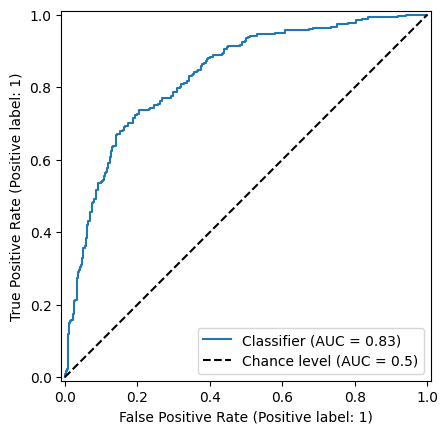

In [17]:
# curva ROC test1
def show_graphic_auc_roc(y_test, y_proba):
  RocCurveDisplay.from_predictions(y_test, y_proba, plot_chance_level=True)

show_graphic_auc_roc(y_test1, y_proba_test1)

In [18]:
# retreina o modelo
df_combined = pd.concat([df_train, df_test1], ignore_index=True)

X_combined = df_combined.drop(columns=target_col)
y_combined = df_combined[target_col[0]]

random_search.fit(X_combined, y_combined)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\gabri\OneDrive\Área de Trabalho\testes_modelos\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gabri\OneDrive\Área de Trabalho\testes_modelos\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__C': array([1.0000...00000000e+02]), 'clf__class_weight': ['balanced', None], 'clf__l1_ratio': array([0. ..., 1. ])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","['roc_auc', 'accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can b

In [19]:
# mostra melhores hiperparâmetros e métricas do treino final
print(show_best_hyperparams())
show_metrics()

melhores hiperparâmetros: {'clf__l1_ratio': np.float64(0.27272727272727276), 'clf__class_weight': 'balanced', 'clf__C': np.float64(0.11768119524349979)}


,rank_test_recall,rank_test_precision,rank_test_f1,rank_test_roc_auc,mean_fit_time,mean_score_time,mean_test_recall,mean_test_precision,mean_test_f1,mean_test_roc_auc
12,17,32,1,2,21.476397,3.515246,0.662963,0.384888,0.486313,0.772900
6,18,30,2,1,22.892019,4.578039,0.662726,0.384918,0.486275,0.772911
21,20,29,3,20,21.008233,3.448730,0.659065,0.386063,0.486254,0.772728
14,16,34,4,5,24.194368,3.958274,0.663173,0.384417,0.485995,0.772879
49,15,35,5,4,15.273581,1.627340,0.663201,0.384394,0.485984,0.772881


In [20]:
# testa o modelo no df_test2
X_test2 = df_test2.drop(columns=target_col)
y_test2 = df_test2[target_col[0]]

y_pred_test2 = random_search.predict(X_test2)
y_proba_test2 = random_search.predict_proba(X_test2)[:, 1]

scores_test2 = calc_scores(y_test2, y_pred_test2, y_proba_test2)
pd.DataFrame(scores_test2, index=["Teste2"])

,accuracy,recall,precision,f1_score,auc_roc
Teste2,0.793978,0.922374,0.808,0.861407,0.833097


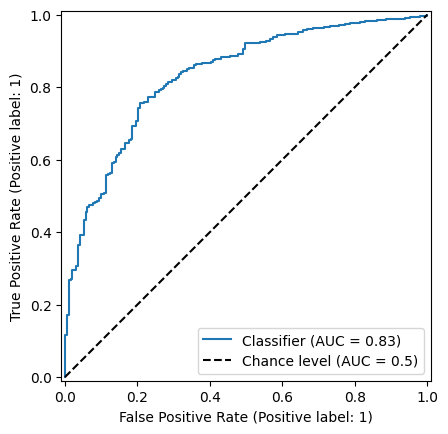

In [21]:
# curva ROC test2
show_graphic_auc_roc(y_test2, y_proba_test2)

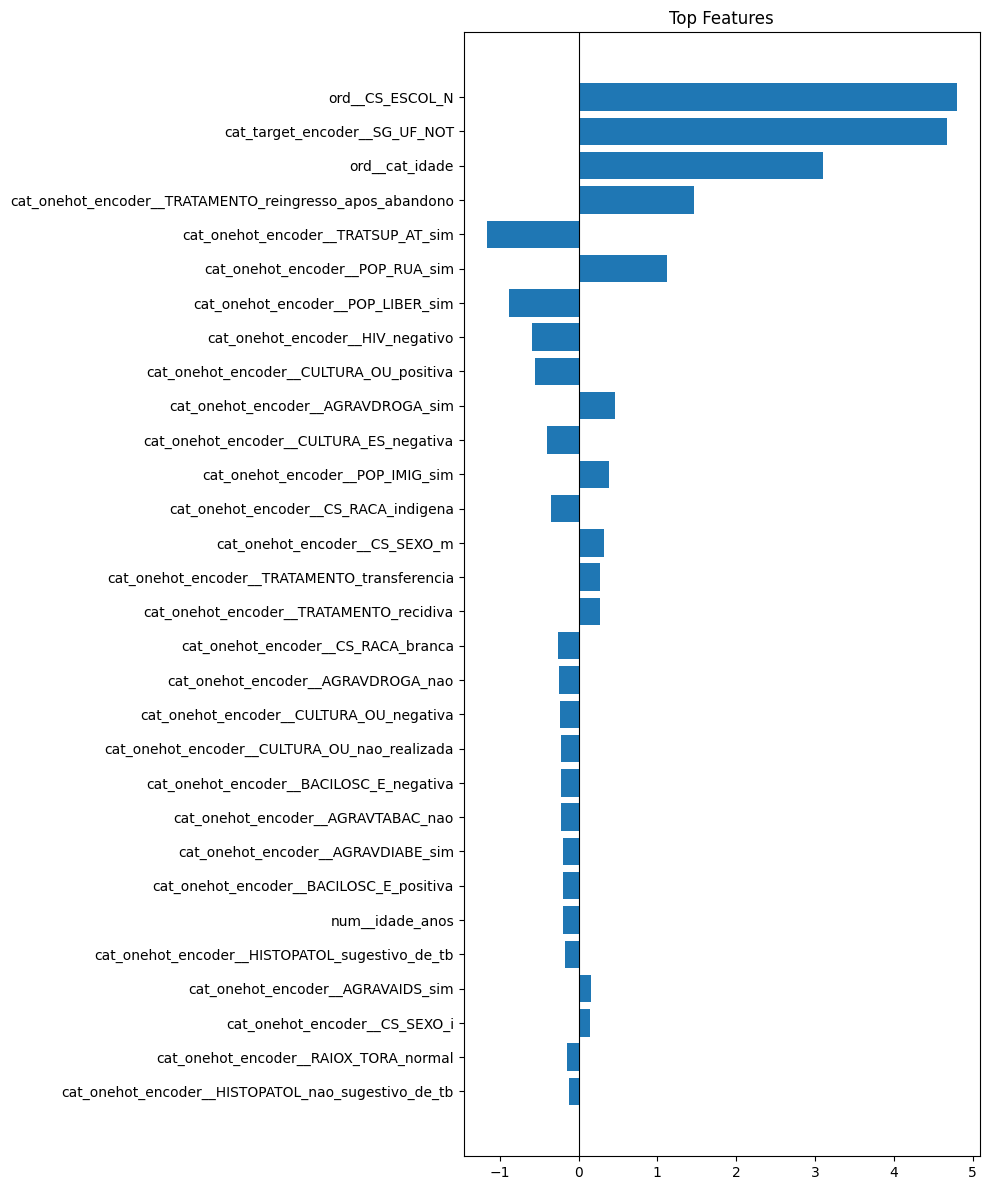

In [22]:
# feature importances
feature_names = random_search.best_estimator_['pre'].get_feature_names_out()
coefficients = random_search.best_estimator_['clf'].coef_[0]

feature_importance_df = pd.DataFrame({'feature':feature_names, 'coef':coefficients})
feature_importance_df['abs_coef'] = np.abs(feature_importance_df['coef'])
feature_importance_df = feature_importance_df.sort_values(by='abs_coef', ascending=False)

top_features = feature_importance_df.head(30)

plt.figure(figsize=(10, 12))
plt.barh(top_features['feature'][::-1], top_features['coef'][::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top Features')
plt.tight_layout()
plt.show()

In [ ]:
# extrai o melhor modelo
import cloudpickle

open('logreg_model.pkl', 'wb').write(cloudpickle.dumps(random_search.best_estimator_))

['logreg_model.pkl']